                **Milestone 4 – Incident Type Analysis**

In [3]:
# 🔹 Advanced-style import block (clean + structured)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Style setup for professional visuals
plt.style.use('ggplot')
sns.set_context("talk")

#  Load dataset safely
file_path = "usnd_cleaned.csv"

try:
    data = pd.read_csv(file_path)
    print("Dataset Loaded Successfully")
except Exception as e:
    print("Error loading dataset:", e)

#  Preview
display(data.sample(5))

#  Column validation
required_cols = ['incidentType','state','year','month','ihProgramDeclared','paProgramDeclared']

missing = [col for col in required_cols if col not in data.columns]

if missing:
    print("Missing columns:", missing)
else:
    print("All required columns present")

Dataset Loaded Successfully


,state,incidentType,declarationDate,year,month
58425,TX,Severe Storm,1990-05-02 00:00:00+00:00,1990,5
17522,AL,Hurricane,2020-09-14 00:00:00+00:00,2020,9
40021,KS,Severe Storm,2009-06-25 00:00:00+00:00,2009,6
49382,MT,Severe Storm,2000-12-06 00:00:00+00:00,2000,12
42155,KS,Severe Storm,2008-02-01 00:00:00+00:00,2008,2


Missing columns: ['ihProgramDeclared', 'paProgramDeclared']


**Incident Type Distribution Analysis**

   incidentType  count
0  Severe Storm  19299
1     Hurricane  13721
2         Flood  11234
3    Biological   7857
4          Fire   3853


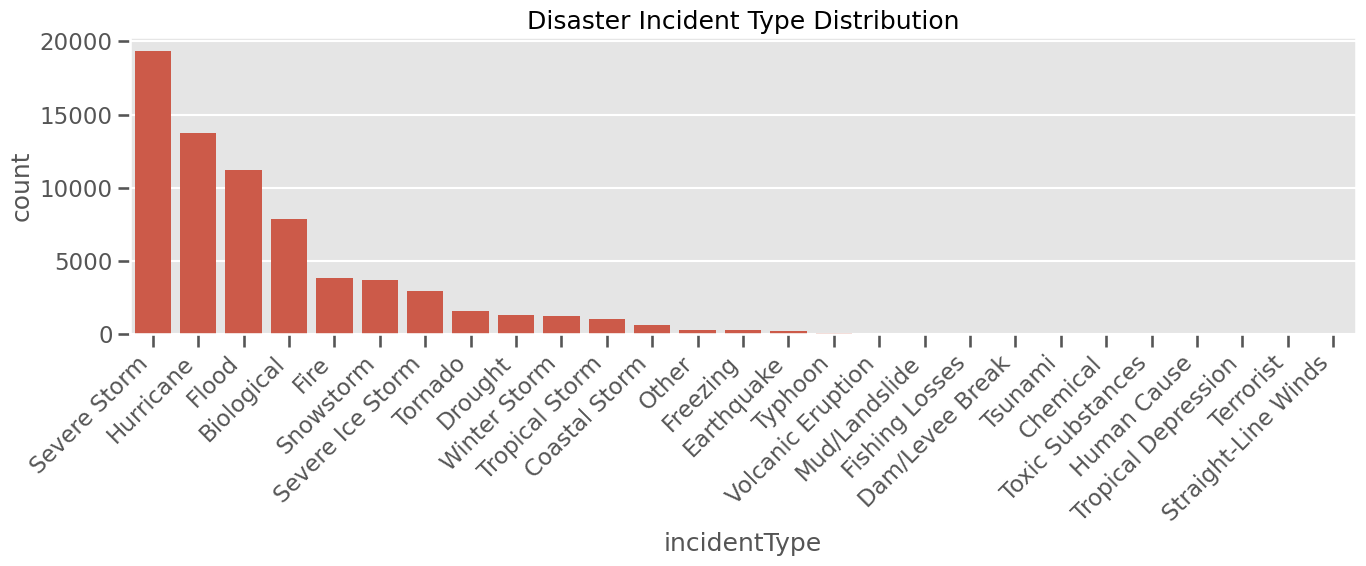

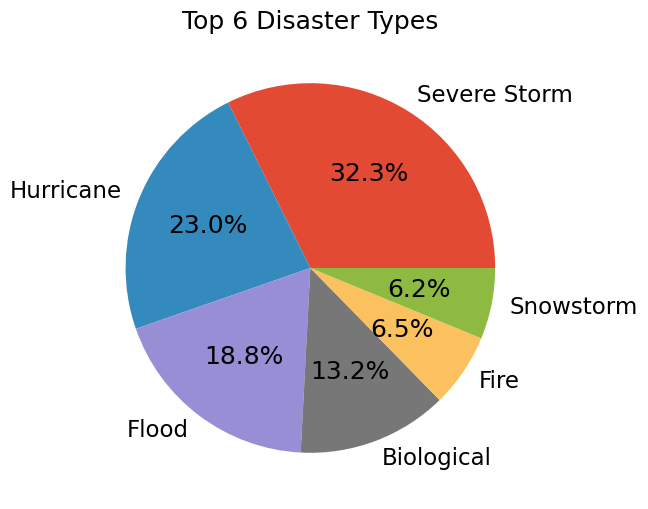

In [4]:
#  Aggregation using method chaining (clean + modern style)
incident_dist = (
    data
    .groupby('incidentType')
    .size()
    .sort_values(ascending=False)
    .reset_index(name='count')
)

print(incident_dist.head())

#  Bar Chart
plt.figure(figsize=(14,6))
sns.barplot(data=incident_dist, x='incidentType', y='count')
plt.xticks(rotation=45, ha='right')
plt.title("Disaster Incident Type Distribution")
plt.tight_layout()
plt.show()

#  Optional: Pie Chart (Top 6 only for clarity)
top6 = incident_dist.head(6)

plt.figure(figsize=(6,6))
plt.pie(top6['count'], labels=top6['incidentType'], autopct='%1.1f%%')
plt.title("Top 6 Disaster Types")
plt.show()

**Interpretation** 

Floods, storms, and hurricanes are the most frequent disaster types.

A few disaster categories dominate the dataset, indicating high concentration of specific disasters.

Rare disaster types (like earthquakes or volcanic activity) appear less frequently.

**Conclusion**
Disaster occurrence is not evenly distributed — certain disaster types are significantly more common.

**State vs Incident Type Analysis**

incidentType  Biological  Chemical  Coastal Storm  Dam/Levee Break  Drought  \
state                                                                         
AK                   121         0              2                0        0   
AL                   139         0              0                0       67   
AR                   152         0              0                0       32   
AS                    10         0              0                0        5   
AZ                    73         0              0                0        8   

incidentType  Earthquake  Fire  Fishing Losses  Flood  Freezing  ...  \
state                                                            ...   
AK                    13    35               0     71        14  ...   
AL                     0    11               0    104         0  ...   
AR                     0     0               0    312         0  ...   
AS                     5     0               0      5         0  ...   
AZ            

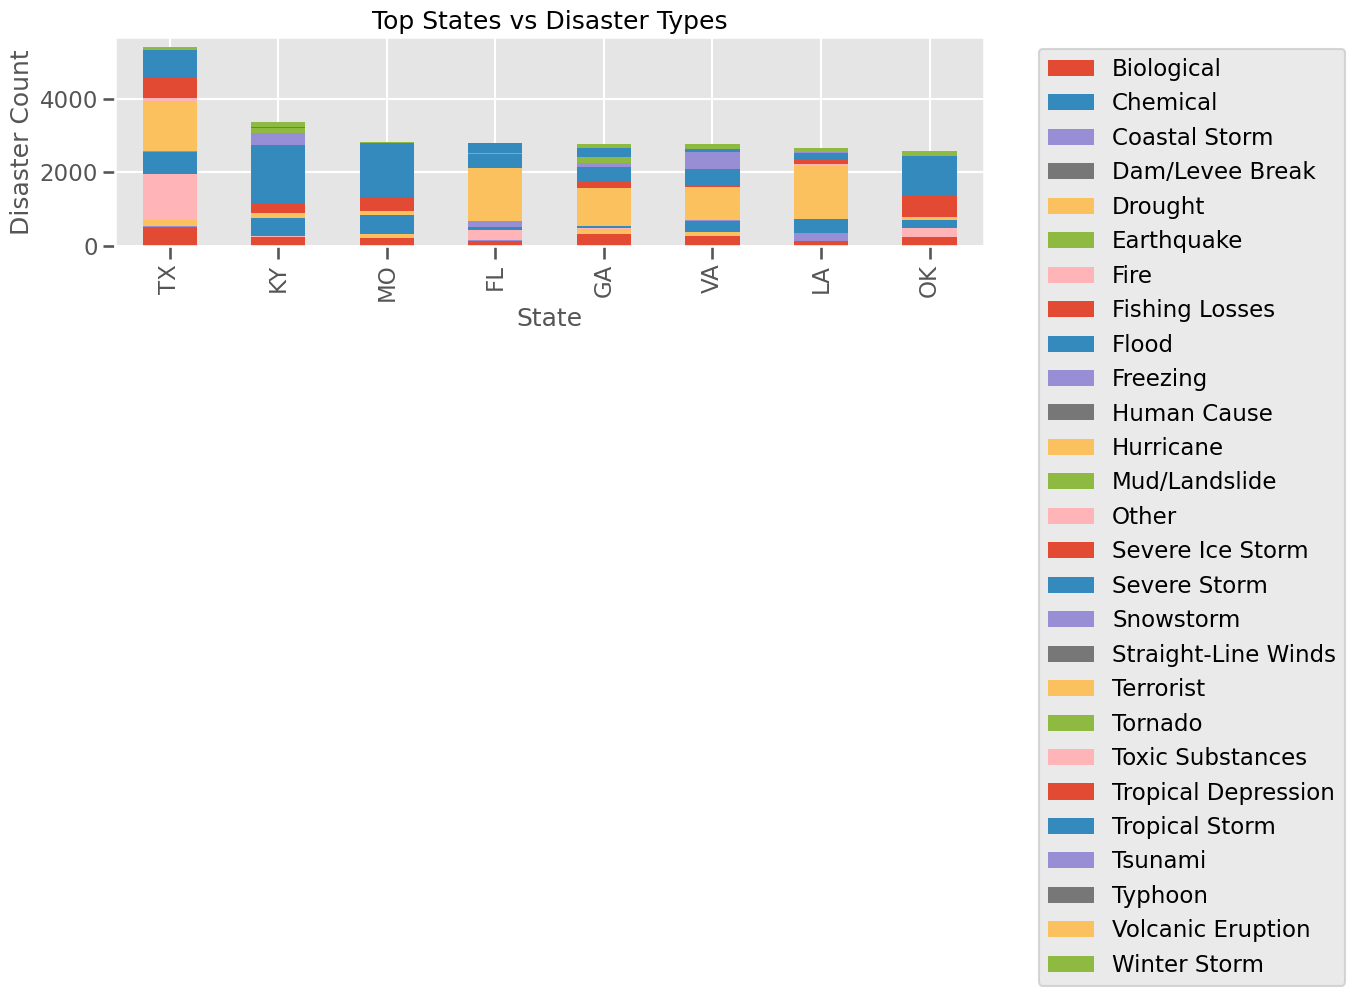

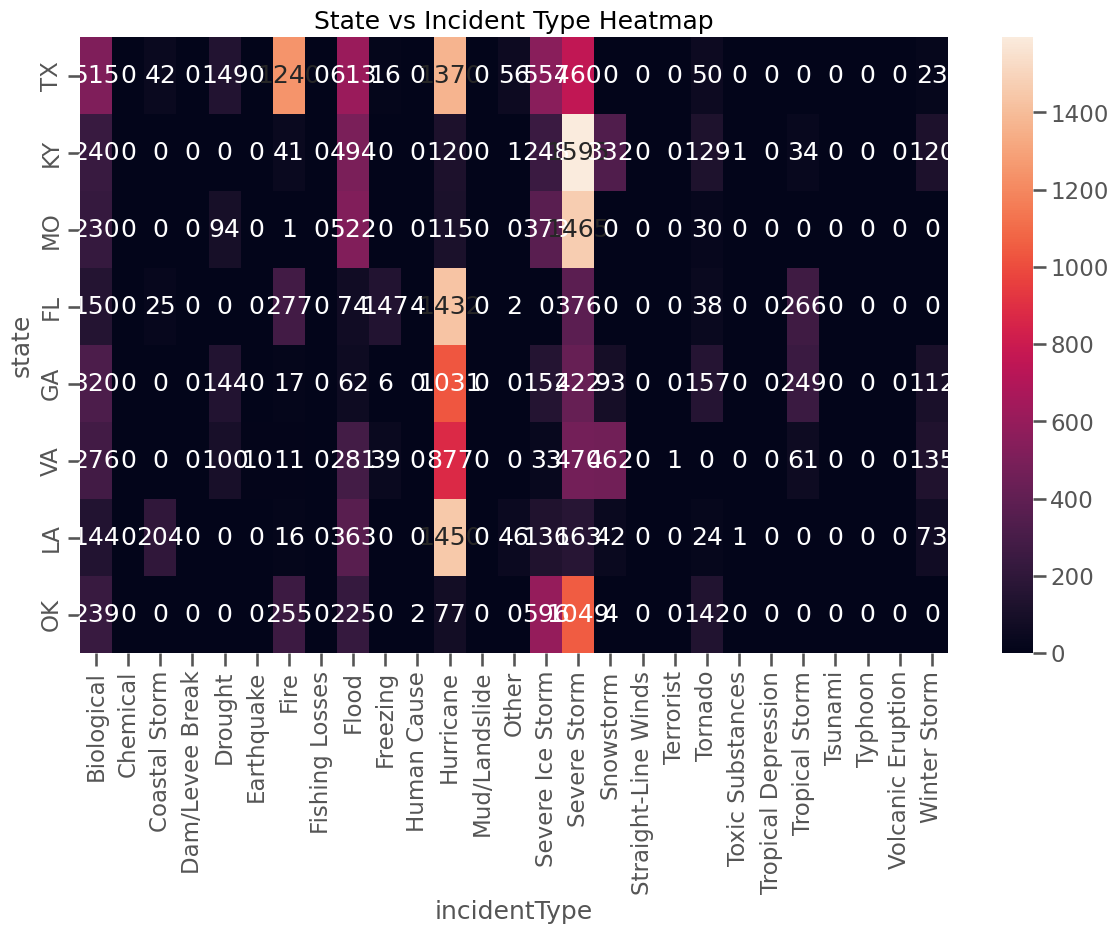

In [8]:
#  Multi-index aggregation
state_incident = (
    data
    .groupby(['state', 'incidentType'])
    .size()
    .unstack(fill_value=0)
)

print(state_incident.head())

#  Stacked Bar Chart (Top 8 states)
top_states = state_incident.sum(axis=1).sort_values(ascending=False).head(8).index

state_incident.loc[top_states].plot(
    kind='bar',
    stacked=True,
    figsize=(14,7)
)

plt.title("Top States vs Disaster Types")
plt.xlabel("State")
plt.ylabel("Disaster Count")
plt.legend(bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

#  Heatmap
plt.figure(figsize=(14,8))
sns.heatmap(state_incident.loc[top_states], annot=True, fmt='d')
plt.title("State vs Incident Type Heatmap")
plt.show()

**Interpretation**
Certain states show strong dominance of specific disasters.
For example:
Coastal states → hurricanes & floods
Central states → storms & severe weather
Heatmap reveals regional disaster patterns clearly.

**Conclusion**
Disasters are geographically dependent, and each state has its own dominant disaster type.